In [1]:
import sys
sys.path.append('../..')
import os

import awkward as ak
import numpy as np
import uproot as uproot
import matplotlib.pyplot as plt
import mplhep as hep
import vector as vec
import matplotlib
from tqdm import tqdm

from Timing.plotting import *

from numba import prange

plt.style.use(hep.style.CMS)
%matplotlib inline

### general methods

In [2]:
from numba import njit
import awkward.numba

@njit
def flatten_numba(a):
    return [x[0] if len(x) else 0 for x in a]

def dist(refEta, refPhi, otherTsEta, otherTsPhi):
    return ((otherTsEta-refEta)**2 + (otherTsPhi-refPhi)**2)**0.5

@njit
def dist_numba(refEta, refPhi, otherTsEta, otherTsPhi):
    out = []
    for i in range(len(otherTsEta)):
        distance = ((otherTsEta[i] - refEta) ** 2 + (otherTsPhi[i] - refPhi) ** 2) ** 0.5
        out.append(distance)
    return np.array(out)

@njit
def distWrap_numba(refEta, refPhi, otherTsEta, otherTsPhi):
    out = []
    for i in range(len(otherTsEta)):
        deltaPhi = otherTsPhi[i] - refPhi
        deltaPhi = (deltaPhi + np.pi) % (2 * np.pi) - np.pi
        distance = ((otherTsEta[i] - refEta) ** 2 + deltaPhi ** 2) ** 0.5
        out.append(distance)
    return np.array(out)
   
def find_track_id(array, number):
    try:
        return np.where(array == number)[0][0]
    except:
        return -1

In [3]:
def load_branch_with_highest_cycle(file, branch_name):
    # Get all keys in the file
    all_keys = file.keys()
    # Filter keys that match the specified branch name
    matching_keys = [key for key in all_keys if key.startswith(branch_name)]
    if not matching_keys:
        raise ValueError(f"No branch with name '{branch_name}' found in the file.")
    # Find the key with the highest cycle
    highest_cycle_key = max(matching_keys, key=lambda key: int(key.split(";")[1]))
    # Load the branch with the highest cycle
    branch = file[highest_cycle_key]
    return branch

### load file

In [4]:
tracksKeys = [
 'track_id',
 'track_hgcal_x',
 'track_hgcal_y',
 'track_hgcal_z',
 'track_hgcal_eta',
 'track_hgcal_phi',
 'track_hgcal_pt',
 'track_pt',
 'track_missing_outer_hits',
#  'track_missing_inner_hits',
#  'track_quality',
#  'track_charge',
#  'track_time',
#  'track_time_quality',
#  'track_time_err',
#  'track_beta',
#  'track_time_mtd',
#  'track_time_mtd_err',
#  'track_pos_mtd',
#  'track_pos_mtd/track_pos_mtd.theVector.theX',
#  'track_pos_mtd/track_pos_mtd.theVector.theY',
#  'track_pos_mtd/track_pos_mtd.theVector.theZ',
#  'track_nhits',
#  'track_isMuon',
#  'track_isTrackerMuon'
]

simTsKeys = [
 'regressed_energy',
 'raw_energy',
 'trackIdx',
 # 'raw_em_energy',
 # 'raw_pt',
 # 'raw_em_pt',
 # 'barycenter_x',
 # 'barycenter_y',
 'barycenter_z',
 'barycenter_eta',
 'barycenter_phi',
 # 'EV1',
 # 'EV2',
 # 'EV3',
 # 'eVector0_x',
 # 'eVector0_y',
 # 'eVector0_z',
 # 'sigmaPCA1',
 # 'sigmaPCA2',
 # 'sigmaPCA3',
 # 'regressed_pt',
 # 'pdgID'
]

assKeys = [
 'ticlTracksterLinks_recoToSim_CP',
 'ticlTracksterLinks_recoToSim_CP_score',
#  'ticlTracksterLinks_recoToSim_CP_sharedE',
 'ticlTracksterLinks_simToReco_CP',
 'ticlTracksterLinks_simToReco_CP_score',
 'ticlTracksterLinks_simToReco_CP_sharedE',
#     'ticlCandidate_simToReco_CP_score',
#     'ticlCandidate_simToReco_CP_sharedE',
 'ticlTracksterLinks_recoToSim_SC',
 'ticlTracksterLinks_recoToSim_SC_score',
#  'ticlTracksterLinks_recoToSim_SC_sharedE',
 'ticlTracksterLinks_simToReco_SC',
 'ticlTracksterLinks_simToReco_SC_score',
 'ticlTracksterLinks_simToReco_SC_sharedE',
#     'ticlCandidate_simToReco_SC_score',
#     'ticlCandidate_simToReco_SC_sharedE'
          ]

tsKeys = [
#  'NTracksters',
#  'NClusters',
 'time',
 'timeError',
 'regressed_energy',
 'raw_energy',
 'raw_em_energy',
 'raw_pt',
 'raw_em_pt',
 'barycenter_x',
 'barycenter_y',
 'barycenter_z',
 'barycenter_eta',
 'barycenter_phi',
#  'EV1',
#  'EV2',
#  'EV3',
#  'eVector0_x',
#  'eVector0_y',
#  'eVector0_z',
#  'sigmaPCA1',
#  'sigmaPCA2',
#  'sigmaPCA3',
#  'id_probabilities',
#  'vertices_indexes',
#  'vertices_x',
#  'vertices_y',
#  'vertices_z',
#  'vertices_time',
#  'vertices_timeErr',
#  'vertices_energy',
#  'vertices_correctedEnergy',
#  'vertices_correctedEnergyUncertainty',
#  'vertices_multiplicity'
]

In [5]:
import os
print(os.listdir())

['.sys.v#.dataMultiPro_SC_fr07_pionPUmoa-err.txt', '.sys.v#.dataMultiPro_SC_fr07_pionPUpre4-err.txt', '.sys.v#.dataMultiPro_SC_fr1_pionPUnew_noErr.txt', '.sys.v#.dataMultiPro_SC_fr1_pionPUpre4-err.txt', '.sys.v#.dataMultiPro_cut1c.txt', '.sys.v#.trackLinkingWindow.ipynb', 'dataMultiPro_SC_fr07_pionPUmoa-err.txt', 'dataMultiPro_SC_fr07_pionPUpre4-err.txt', 'dataMultiPro_SC_fr1_pionPUnew_noErr.txt', 'dataMultiPro_SC_fr1_pionPUpre4-err.txt', 'dataMultiPro_cut1c.txt', 'plots', 'plotsWindow', 'runs.sh', 'trackLinkingWindow.ipynb', 'trackLinkingWindow.py', 'trackLinkingWindowCLUE3D.py']


In [6]:
# 10 - 2 done
# 50 - 2 done
#100 - 2 done
# 10 - 2.5 done
# 50 - 2.5 
#100 - 2.5 

In [7]:
label = "pt10_eta1p7"
PU = "_Pi_"+label+"_200"
# file = uproot.open("TTbar_PU200_1500pre1.root")
# file = uproot.open("/eos/user/a/aperego/SampleProduction/TICLv5/ParticleGunPionPU/histo_"+label+"/SinglePi_PU_"+label+".root")
file = uproot.open("/eos/user/a/aperego/SampleProduction/TICLv5/ParticleGunPionPU/histo_"+label+"/histo_8032616_0.root")

In [8]:
#file = uproot.open("/eos/user/a/aperego/BDT/histo.root")

In [9]:
file.keys()

['ticlDumper;1',
 'ticlDumper/clusters;4',
 'ticlDumper/clusters;3',
 'ticlDumper/ticlTrackstersCLUE3DHigh;2',
 'ticlDumper/ticlTrackstersCLUE3DHigh;1',
 'ticlDumper/ticlTracksterLinks;2',
 'ticlDumper/ticlTracksterLinks;1',
 'ticlDumper/ticlCandidate;2',
 'ticlDumper/ticlCandidate;1',
 'ticlDumper/ticlTracksterLinksSuperclusteringDNN;1',
 'ticlDumper/simtrackstersSC;1',
 'ticlDumper/simtrackstersCP;1',
 'ticlDumper/candidates;1',
 'ticlDumper/superclustering;1',
 'ticlDumper/associations;1',
 'ticlDumper/tracks;1',
 'ticlDumper/simTICLCandidate;1']

In [15]:
alltracksters = load_branch_with_highest_cycle(file,'ticlDumper/ticlTrackstersCLUE3DHigh')
allsimtrackstersCP = load_branch_with_highest_cycle(file, 'ticlDumper/simtrackstersCP')
allsimtrackstersSC = load_branch_with_highest_cycle(file, 'ticlDumper/simtrackstersSC')
allassociations = load_branch_with_highest_cycle(file, 'ticlDumper/associations')
alltracks = load_branch_with_highest_cycle(file, 'ticlDumper/tracks')
allticlTracksterLinks = load_branch_with_highest_cycle(file, 'ticlDumper/ticlTracksterLinks')


simtrackstersCP = allsimtrackstersCP.arrays(simTsKeys)
simtrackstersSC = allsimtrackstersSC.arrays(simTsKeys)
# tracksters = alltracksters.arrays(tsKeys)
associations = allassociations.arrays(assKeys)
tracks = alltracks.arrays(tracksKeys)
tracksterLinks = allticlTracksterLinks.arrays(tsKeys)

In [16]:
allassociations.keys()

['event',
 'event/run_',
 'event/luminosityBlock_',
 'event/event_',
 'ticlTrackstersCLUE3DHigh_recoToSim_SC',
 'ticlTrackstersCLUE3DHigh_recoToSim_SC_score',
 'ticlTrackstersCLUE3DHigh_recoToSim_SC_sharedE',
 'ticlTrackstersCLUE3DHigh_simToReco_SC',
 'ticlTrackstersCLUE3DHigh_simToReco_SC_score',
 'ticlTrackstersCLUE3DHigh_simToReco_SC_sharedE',
 'ticlTracksterLinks_recoToSim_SC',
 'ticlTracksterLinks_recoToSim_SC_score',
 'ticlTracksterLinks_recoToSim_SC_sharedE',
 'ticlTracksterLinks_simToReco_SC',
 'ticlTracksterLinks_simToReco_SC_score',
 'ticlTracksterLinks_simToReco_SC_sharedE',
 'ticlCandidate_recoToSim_SC',
 'ticlCandidate_recoToSim_SC_score',
 'ticlCandidate_recoToSim_SC_sharedE',
 'ticlCandidate_simToReco_SC',
 'ticlCandidate_simToReco_SC_score',
 'ticlCandidate_simToReco_SC_sharedE',
 'ticlTracksterLinksSuperclusteringDNN_recoToSim_SC',
 'ticlTracksterLinksSuperclusteringDNN_recoToSim_SC_score',
 'ticlTracksterLinksSuperclusteringDNN_recoToSim_SC_sharedE',
 'ticlTracksterLi

(array([ 2.,  3.,  8., 29., 41., 10.,  3.,  2.,  0.,  2.]),
 array([11.16155624, 14.47585583, 17.79015541, 21.10445404, 24.41875458,
        27.73305321, 31.04735184, 34.36165237, 37.67595291, 40.99024963,
        44.30455017]),
 <BarContainer object of 10 artists>)

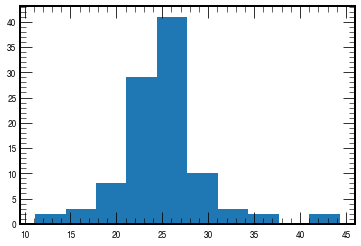

In [12]:
plt.hist(ak.flatten(simtrackstersCP.raw_energy))

Text(1, 0, 'simToReco score')

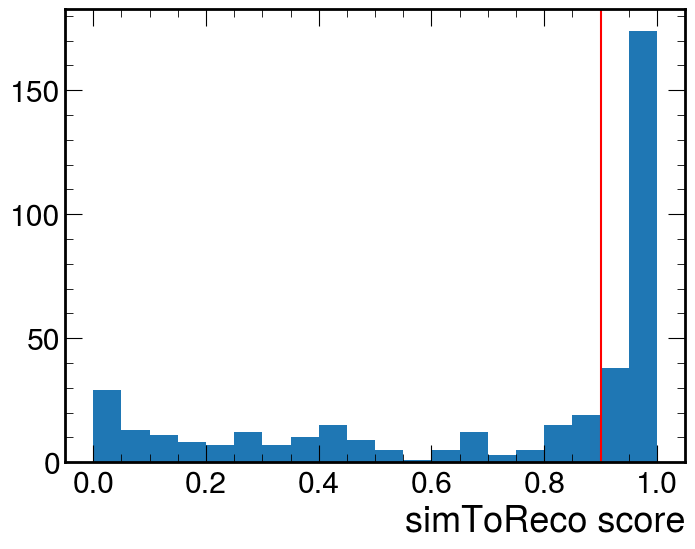

In [13]:
plt.figure(dpi=100, figsize=(8,6))
plt.style.use(hep.style.CMS)
plt.axvline(0.9, color="red")
plt.hist(ak.flatten(ak.flatten(associations.ticlTracksterLinks_simToReco_SC_score)), bins=20)
plt.xlabel("simToReco score")

In [18]:
associations = allassociations.arrays(allassociations.keys())

In [20]:
print(associations.ticlCandidate_simToReco_CP_score[0])
print(associations.ticlCandidate_simToReco_CP[0])

[[0.128], [0.373, 0.894, 1, 1]]
[[21], [14, 15, 857, 670]]


In [21]:
allcands = load_branch_with_highest_cycle(file, 'ticlDumper/candidates')
cands = allcands.arrays(allcands.keys())
print(allcands.keys())

['event', 'event/run_', 'event/luminosityBlock_', 'event/event_', 'NCandidates', 'candidate_charge', 'candidate_pdgId', 'candidate_id_probabilities', 'candidate_time', 'candidate_timeErr', 'candidate_energy', 'candidate_raw_energy', 'candidate_px', 'candidate_py', 'candidate_pz', 'candidate_pt', 'candidate_phi', 'candidate_eta', 'track_in_candidate', 'tracksters_in_candidate']


In [22]:
cands.tracksters_in_candidate[0]G

<Array [[0], [], [], ..., [1037], [1038], [1039]] type='1396 * var * uint32'>

In [21]:
distanceSameList = []
distanceOthersList = []

# First loop: Compute and store distances
for ev in tqdm(prange(10)): #len(simtrackstersCP))):
    stsCPEv = simtrackstersCP[ev]
    tracksEv = tracks[ev]
    tsLinksEv = tracksterLinks[ev]
    assEv = associations[ev]
    print(ev)

    for idx in prange(len(stsCPEv.trackIdx)):
        trk_id = find_track_id(tracksEv.track_id, stsCPEv.trackIdx[idx])
        if trk_id == -1:
            continue

        refEta = tracksEv.track_hgcal_eta[trk_id]
        refPhi = tracksEv.track_hgcal_phi[trk_id]

        maskScore = assEv.ticlTracksterLinks_simToReco_CP_score[idx] < 0.8
        tsEnergy = tsLinksEv.raw_energy[assEv.ticlTracksterLinks_simToReco_CP[idx]]
        sharedEnergy = assEv.ticlTracksterLinks_simToReco_CP_sharedE[idx]
        maskEnergy = sharedEnergy / tsEnergy > 0.6
        assIndices = assEv.ticlTracksterLinks_simToReco_CP[idx]
        bad = []
        for recoIdx in assIndices:
            idx_in_r2s = np.where(idx==assEv.ticlTracksterLinks_recoToSim_CP[recoIdx])[0][0]
#             print(np.where(idx==assEv.ticlTracksterLinks_recoToSim_CP[recoIdx])[0][0])
            if assEv.ticlTracksterLinks_recoToSim_CP_score[recoIdx][idx_in_r2s] > 0.6:
                bad.append(recoIdx)
        
        maskIdx = assIndices[maskScore & maskEnergy]
#         print(f"{assIndices=}, {maskIdx=}, {bad=}", np.setdiff1d(maskIdx, bad))
        notMaskIdx = assIndices[~(maskScore & maskEnergy)] # np.setdiff1d(np.arange(len(array)), mask)

        sameTsEta = tsLinksEv.barycenter_eta[maskIdx]
        sameTsPhi = tsLinksEv.barycenter_phi[maskIdx]
        otherTsEta = tsLinksEv.barycenter_eta[notMaskIdx]
        otherTsPhi = tsLinksEv.barycenter_phi[notMaskIdx]

        if len(sameTsEta):
            distanceSameList.append(distWrap_numba(refEta, refPhi, sameTsEta, sameTsPhi))
            print(distanceSameList[-1])
        else:
            continue
        
        if len(otherTsEta):
            distanceOthersList.append(distWrap_numba(refEta, refPhi, otherTsEta, otherTsPhi))
            print(distanceOthersList[-1])
        else:
            distanceOthersList.append([])   

  0%|          | 0/10 [00:00<?, ?it/s]

0


100%|██████████| 10/10 [00:04<00:00,  2.03it/s]

[0.00771216]
[0.00260135]
[0.03097639 0.10849224 0.21687666]
1
[0.02739593]
[0.02841954 0.23038755 0.01822152 0.09942477 0.22099838 0.97013001
 0.8969271  1.0979623  1.21403789 1.29016177 0.32615652 1.47460262
 1.33154847 0.20544792 1.47145028 1.17394679 1.15718689 0.95746748]
[0.02255399]
[0.11422052 0.06643955 0.27649245 0.1743647 ]
2
[0.00171647]
[0.03041463 0.04566821]
3
[0.6381778]
[0.01001343]
[0.00741462]
[0.02617793 0.10460767]
4
[0.02106677]
[0.07477285 0.3066808  0.22147428]
[0.0112284]
[0.01332722]
5
[0.00610406]
[0.13587337]
[0.0099323]
[0.11020865 1.35309528]
6
[0.00970637]
[0.09652119]
7
[0.01074841]
[0.02243037]
[0.04586046]
8
[0.00948389]
[0.00932411]
[0.06518863]
9
[0.24296562]
[0.0121153  0.00987639]
[0.00239363]


In [69]:
MAX = 1
NPOINTS = 100
thresholds = np.linspace(0, MAX, NPOINTS)

distanceSameArray = np.array(distanceSameList, dtype=object)
distanceOthersArray = np.array(distanceOthersList, dtype=object)

allFractionsSame = np.zeros(NPOINTS)
allCountsSame = np.zeros(NPOINTS)
allFractionsOthers = np.zeros(NPOINTS)
allCountsOthers = np.zeros(NPOINTS)
counter = 0

# Lists to store per-event values for plotting
fractionsSameList = []
countsSameList = []
fractionsOthersList = []
countsOthersList = []

for distanceSame, distanceOthers in tqdm(zip(distanceSameArray, distanceOthersArray)):
    countsSame = np.less.outer(distanceSame, thresholds).sum(axis=0)  # Vectorized comparison
    fractionsSame = countsSame / len(distanceSame)

    if len(distanceOthers):
        countsOthers = np.less.outer(distanceOthers, thresholds).sum(axis=0)
        fractionsOthers = countsOthers / len(distanceOthers)
        counter += 1
    else:
        countsOthers = np.zeros_like(thresholds)
        fractionsOthers = np.zeros_like(thresholds)

    # Store results for plotting later
    fractionsSameList.append(fractionsSame)
    countsSameList.append(countsSame)
    fractionsOthersList.append(fractionsOthers)
    countsOthersList.append(countsOthers)

    # Aggregate totals
    allFractionsSame += fractionsSame
    allCountsSame += countsSame
    allFractionsOthers += fractionsOthers
    allCountsOthers += countsOthers

9it [00:00, 10922.67it/s]


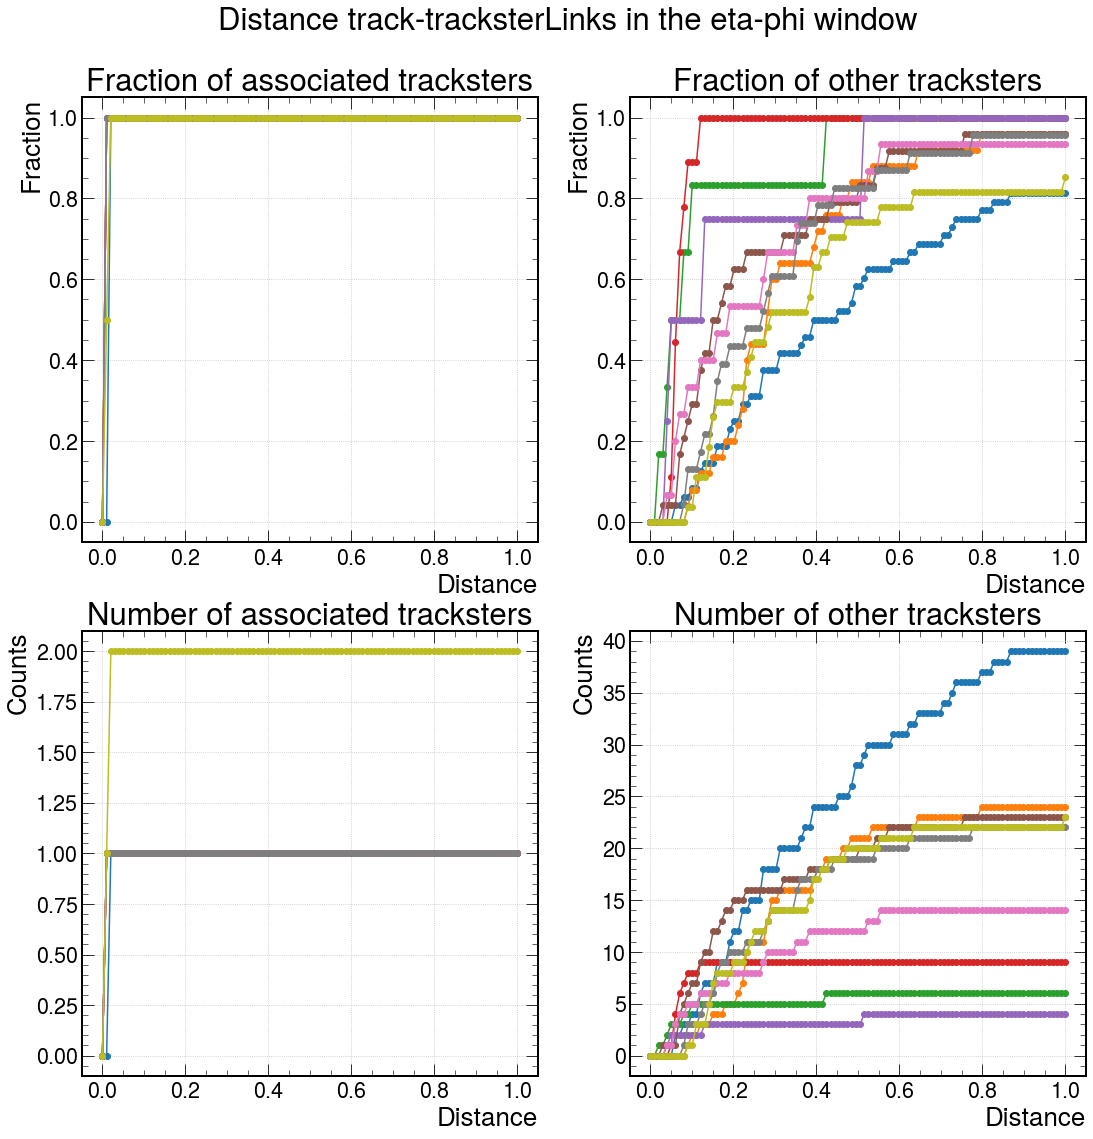

In [70]:
fig, axs = plt.subplots(2, 2, figsize=(18, 18))
fig.suptitle("Distance track-tracksterLinks in the eta-phi window", y=0.95)
ax1, ax2, ax3, ax4 = axs[0][0], axs[1][0], axs[0][1], axs[1][1]
plt.style.use(hep.style.CMS)

# Plot per-event data
for fractionsSame, countsSame, fractionsOthers, countsOthers in zip(
    fractionsSameList, countsSameList, fractionsOthersList, countsOthersList
):
    ax1.plot(thresholds, fractionsSame, marker='o', linestyle='-')
    ax2.plot(thresholds, countsSame, marker='o', linestyle='-')
    ax3.plot(thresholds, fractionsOthers, marker='o', linestyle='-')
    ax4.plot(thresholds, countsOthers, marker='o', linestyle='-')

# Labels and formatting
ax1.set_xlabel("Distance")
ax1.set_ylabel("Fraction")
ax1.set_title("Fraction of associated tracksters")
ax1.grid(True)

ax2.set_xlabel("Distance")
ax2.set_ylabel("Counts")
ax2.set_title("Number of associated tracksters")
ax2.grid(True)

ax3.set_xlabel("Distance")
ax3.set_ylabel("Fraction")
ax3.set_title("Fraction of other tracksters")
ax3.grid(True)

ax4.set_xlabel("Distance")
ax4.set_ylabel("Counts")
ax4.set_title("Number of other tracksters")
ax4.grid(True)

plt.show()
# plt.savefig(f"plots/NtrackstersInWindow{PU}PU.png")

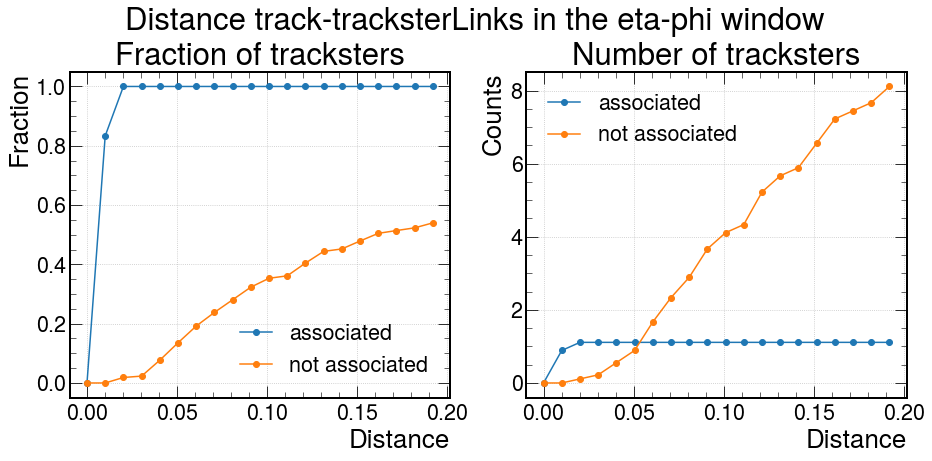

In [71]:
# Plot results
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Distance track-tracksterLinks in the eta-phi window", y=1.03)
plt.style.use(hep.style.CMS)

ax1, ax2 = axs[0], axs[1]

ax1.plot(thresholds[:20], allFractionsSame[:20] / len(distanceSameList), marker='o', linestyle='-', label='associated')
ax1.plot(thresholds[:20], allFractionsOthers[:20] / counter, marker='o', linestyle='-', label='not associated')
ax1.set_xlabel("Distance")
ax1.set_ylabel("Fraction")
ax1.set_title("Fraction of tracksters")
ax1.legend()
ax1.grid(True)

ax2.plot(thresholds[:20], allCountsSame[:20] / len(distanceSameList), marker='o', linestyle='-', label='associated')
ax2.plot(thresholds[:20], allCountsOthers[:20] / counter, marker='o', linestyle='-', label='not associated')
ax2.set_xlabel("Distance")
ax2.set_ylabel("Counts")
ax2.set_title("Number of tracksters")
ax2.legend()
ax2.grid(True)

plt.show()
#plt.savefig(f"plots/cumulativeNtrackstersInWindow{PU}PU.png")

In [72]:
# MAX=4
# # Thresholds from 0 to 1 in small steps
# thresholds = np.linspace(0, MAX, 100)

# ts_info = []
# fig, axs = plt.subplots(2, 2, figsize=(15,15))
# fig.suptitle("Distance track-tracksters in the eta-phi window", y=0.95)
# ax1 = axs[0][0]
# ax2 = axs[1][0]
# ax3 = axs[0][1]
# ax4 = axs[1][1]
# plt.style.use(hep.style.CMS)

# allFractionsSame = np.zeros(100)
# allCountsSame = np.zeros(100)
# allFractionsOthers = np.zeros(100)
# allCountsOthers = np.zeros(100)
# counter=0

# for ev in prange(len(simtrackstersCP)):
# #     print(f"\nProcessing event {ev}")  # Debug
#     stsCPEv = simtrackstersCP[ev]
#     tracksEv = tracks[ev]
#     tsLinksEv = tracksterLinks[ev]
#     assEv = associations[ev]
# #     print(f"Number of track indices in stsCPEv: {len(stsCPEv.trackIdx)}")  # Debug

#     for idx in range(len(stsCPEv.trackIdx)):
#         trk_id = find_track_id(tracksEv.track_id, stsCPEv.trackIdx[idx])
# #         print(f"Index: {idx}, Track ID found: {trk_id}")  # Debug
#         if trk_id == -1: 
# #             print("Track ID not found, skipping...")  # Debug
#             continue

#         refEta = tracksEv.track_hgcal_eta[trk_id]
#         refPhi = tracksEv.track_hgcal_phi[trk_id]
# #         print(f"Reference Track Eta: {refEta}, Phi: {refPhi}")  # Debug

#         maskScore = assEv.ticlTracksterLinks_simToReco_CP_score[idx] < 0.7 
#         tsEnergy = tsLinksEv.raw_energy[assEv.ticlTracksterLinks_simToReco_CP[idx]]
#         maskEnergy = assEv.ticlTracksterLinks_simToReco_CP_sharedE[idx] / tsEnergy > 0.3
# #         print(f"raw enrgy: {tsLinksEv.raw_energy}, maskId: {assEv.ticlTracksterLinks_simToReco_CP[idx]}, {tsEnergy=},\n {maskEnergy=},  {maskScore=}")
# #         print(f" both: {maskScore & maskEnergy}")
#         maskIdx = assEv.ticlTracksterLinks_simToReco_CP[idx][maskScore & maskEnergy]
# #         print(f"{maskIdx=}")  # Debug

#         sameTsEta = tsLinksEv.barycenter_eta[maskIdx]
#         sameTsPhi = tsLinksEv.barycenter_phi[maskIdx]
# #         print(f"Same Trackster Eta: {sameTsEta}")  # Debug
# #         print(f"Same Trackster Phi: {sameTsPhi}")  # Debug

#         if not len(sameTsEta): 
# #             print("No same trackster entries found, skipping...")  # Debug
#             continue

#         notMaskIdx = assEv.ticlTracksterLinks_simToReco_CP[idx][~maskScore] # np.setdiff1d(np.arange(len(tsLinksEv.barycenter_phi)), maskIdx)
#         otherTsEta = tsLinksEv.barycenter_eta[notMaskIdx]
#         otherTsPhi = tsLinksEv.barycenter_phi[notMaskIdx]
# #         print(f"nTs = {len(tsLinksEv.barycenter_phi)}, {notMaskIdx=}")
# #         print(f"Other Trackster Eta: {otherTsEta}")  # Debug
# #         print(f"Other Trackster Phi: {otherTsPhi}")  # Debug

#         distanceSame = distWrap_numba(refEta, refPhi, sameTsEta, sameTsPhi)
#         fractionsSame = [np.sum(distanceSame < t)/len(distanceSame) for t in thresholds] 
#         countsSame = [np.sum(distanceSame < t) for t in thresholds]
        
#         distanceOthers = distWrap_numba(refEta, refPhi, otherTsEta, otherTsPhi)
#         if not len(distanceOthers):
#             fractionsOthers = np.zeros(100)
#             countsOthers = np.zeros(100)
#         else:
#             fractionsOthers = [np.sum(distanceOthers < t)/len(distanceOthers) for t in thresholds] 
#             countsOthers = [np.sum(distanceOthers < t) for t in thresholds] 
        
# #         print(f"distanceSame: {distanceSame}")
# #         print(f"fractionsSame: {fractionsSame}")
# #         print(f"countsSame: {countsSame}")
        
# #         print(f"distanceOthers: {distanceOthers}")
# #         print(f"fractionsOthers: {fractionsOthers}")
# #         print(f"countsOthers: {countsOthers}")
        
#         # Plot
#         ax1.plot(thresholds, fractionsSame, marker='o', linestyle='-')
#         ax1.set_xlabel("Distance")
#         ax1.set_ylabel("Fraction")
#         ax1.set_title("Fraction of assoc TracksterLinks")
#         ax1.grid(True)
#         ax2.plot(thresholds, countsSame, marker='o', linestyle='-')
#         ax2.set_xlabel("Distance")
#         ax2.set_ylabel("Counts")
#         ax2.set_title("Number of assoc TracksterLinks")
#         ax2.grid(True)
#         ax3.plot(thresholds, fractionsOthers, marker='o', linestyle='-')
#         ax3.set_xlabel("Distance")
#         ax3.set_ylabel("Fraction")
#         ax3.set_title("Fraction of TracksterLinks")
#         ax3.grid(True)
#         ax4.plot(thresholds, countsOthers, marker='o', linestyle='-')
#         ax4.set_xlabel("Distance")
#         ax4.set_ylabel("Counts")
#         ax4.set_title("Number of TracksterLinks")
#         ax4.grid(True)
        
#         allFractionsSame += fractionsSame
#         allCountsSame += countsSame
#         allFractionsOthers += fractionsOthers
#         allCountsOthers += countsOthers
#         counter+=1
# plt.show()

# fig, axs = plt.subplots(2, 2, figsize=(15,15))
# fig.suptitle("Distance track-tracksters in the eta-phi window", y=0.95)
# ax1 = axs[0][0]
# ax2 = axs[1][0]
# ax3 = axs[0][1]
# ax4 = axs[1][1]
# plt.style.use(hep.style.CMS)
# ax1.plot(thresholds, allFractionsSame/counter, marker='o', linestyle='-')
# ax1.set_xlabel("Distance")
# ax1.set_ylabel("Fraction")
# ax1.set_title("Fraction of assoc TracksterLinks")
# ax1.grid(True)
# ax2.plot(thresholds, allCountsSame/counter, marker='o', linestyle='-')
# ax2.set_xlabel("Distance")
# ax2.set_ylabel("Counts")
# ax2.set_title("Number of assoc TracksterLinks")
# ax2.grid(True)
# ax3.plot(thresholds, allFractionsOthers/counter, marker='o', linestyle='-')
# ax3.set_xlabel("Distance")
# ax3.set_ylabel("Fraction")
# ax3.set_title("Fraction of TracksterLinks")
# ax3.grid(True)
# ax4.plot(thresholds, allCountsOthers/counter, marker='o', linestyle='-')
# ax4.set_xlabel("Distance")
# ax4.set_ylabel("Counts")
# ax4.set_title("Number of TracksterLinks")
# ax4.grid(True)
# plt.show()

In [31]:
sharedE_reco = []
sharedE_sim = []
for ev in tqdm(range(10)): #prange(len(simtrackstersCP))):
    stsCPEv = simtrackstersSC[ev]
    tsLinksEv = tracksterLinks[ev]
    assEv = associations[ev]

    for idx in prange(len(stsCPEv.trackIdx)):
        tsEnergy = tsLinksEv.raw_energy[assEv.ticlTracksterLinks_simToReco_SC[idx]]
        sharedEnergy = (assEv.ticlTracksterLinks_simToReco_SC_sharedE[idx]) #[assEv.ticlTracksterLinks_recoToSim_CP[idx]>0.6]
        sharedE_reco.extend(sharedEnergy / tsEnergy)
        sharedE_sim.extend(sharedEnergy / stsCPEv.raw_energy[idx])

100%|██████████| 10/10 [00:00<00:00, 68.94it/s]


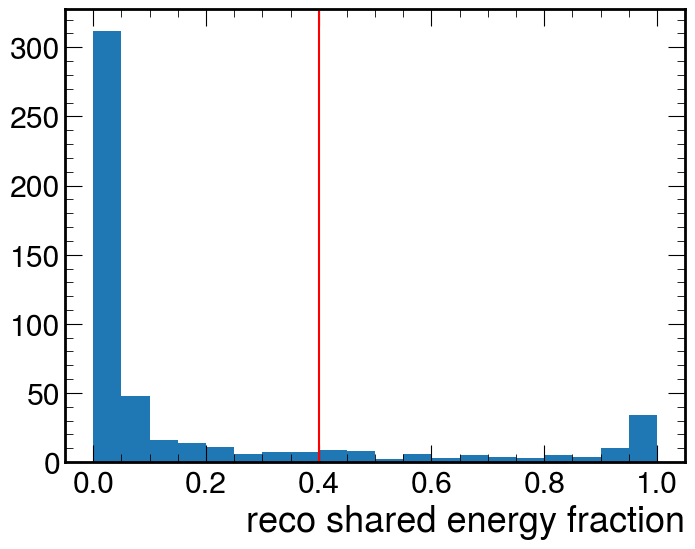

In [32]:
plt.figure(dpi=100, figsize=(8,6))
plt.style.use(hep.style.CMS)
plt.axvline(0.4, color="red")
plt.hist(sharedE_reco, bins =20)
plt.xlabel("reco shared energy fraction")
plt.show()

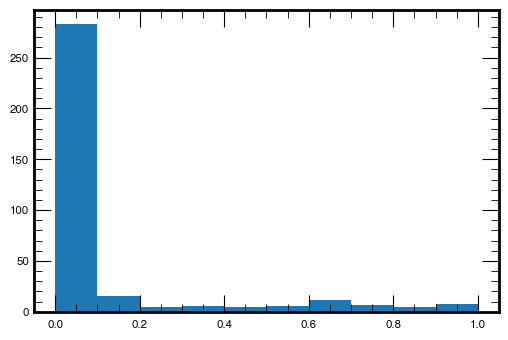

In [36]:
plt.figure(dpi=100)
plt.hist(sharedE_sim)
plt.show()

In [22]:
distanceSharedList = []
distanceTotalList = []
energySharedList = []
energyTotalList = []
fractionSharedList = []
fractionTotalList = []
fractionPileupList = []
data = []

for ev in tqdm(prange(len(simtrackstersSC))):
    stsSCEv = simtrackstersSC[ev]
    tracksEv = tracks[ev]
    tsLinksEv = tracksterLinks[ev]
    assEv = associations[ev]
    print("--- ", ev, " ---")
    for idx in prange(len(stsSCEv.trackIdx)):
        trk_id = find_track_id(tracksEv.track_id, stsSCEv.trackIdx[idx])
        if trk_id == -1:
            continue

        refEta = tracksEv.track_hgcal_eta[trk_id]
        refPhi = tracksEv.track_hgcal_phi[trk_id]       
        refPt = tracksEv.track_hgcal_pt[trk_id]       

        ##########
        maskScore = assEv.ticlTracksterLinks_simToReco_SC_score[idx] < 0.9
        tsEnergy = tsLinksEv.raw_energy[assEv.ticlTracksterLinks_simToReco_SC[idx]]
        sharedEnergy = assEv.ticlTracksterLinks_simToReco_SC_sharedE[idx]
        maskEnergy = sharedEnergy / tsEnergy > 0.4
        assIndices = assEv.ticlTracksterLinks_simToReco_SC[idx]
#         print(sharedEnergy[:3], sharedEnergy[:3] / tsEnergy[:3])
        maskIdx = assIndices[maskScore & maskEnergy]
#         good = []
#         for recoIdx in maskIdx:
#             idx_in_r2s = np.where(idx==assEv.ticlTracksterLinks_recoToSim_CP[recoIdx])[0][0]
# #             print(np.where(idx==assEv.ticlTracksterLinks_recoToSim_CP[recoIdx])[0][0])
#             if assEv.ticlTracksterLinks_recoToSim_CP_score[recoIdx][idx_in_r2s] < 0.6:
#                 good.append(recoIdx)
        
# #         print(f"{assIndices=}, {maskIdx=}, {good=}")
#         #########
        
        assIndices = maskIdx
        sharedEnergy = sharedEnergy[maskScore & maskEnergy]
        
        allTsEta = tsLinksEv.barycenter_eta[tsLinksEv.barycenter_eta * refEta > 0]
        allTsPhi = tsLinksEv.barycenter_phi[tsLinksEv.barycenter_eta * refEta > 0]
        allTsEnergy = tsLinksEv.raw_energy[tsLinksEv.barycenter_eta * refEta > 0]
        shareTsEta = tsLinksEv.barycenter_eta[assIndices]
        shareTsPhi = tsLinksEv.barycenter_phi[assIndices] 
        tsEnergy = tsLinksEv.raw_energy[assIndices] 
        
        print("-- ts --")
        if len(shareTsEta):
            d1 = distWrap_numba(refEta, refPhi, shareTsEta, shareTsPhi)
            idx_sort = np.array(d1).argsort()
            d1_sorted = d1[idx_sort]
            distanceSharedList.append(d1_sorted)
            sharedEnergy_sorted = sharedEnergy[idx_sort]
            energySharedList.append(np.cumsum(sharedEnergy_sorted))
            fractionSharedList.append(np.cumsum(sharedEnergy_sorted) / np.sum(sharedEnergy_sorted)) #FIX!! sharedEnergy_sorted or tsEnergy[idx_sort]
            print(sharedEnergy_sorted, tsEnergy[idx_sort], sharedEnergy_sorted / tsEnergy[idx_sort], 1. - sharedEnergy_sorted / tsEnergy[idx_sort], np.cumsum(1. - (sharedEnergy_sorted / tsEnergy[idx_sort]))[-1])
            fractionPileupList.append(np.cumsum(1. - (sharedEnergy_sorted / tsEnergy[idx_sort])))
            
            #distanceSharedList at which fractionSharedList == 1
            idx_R = np.where(fractionSharedList[-1]==1)[0][0] #CUT HERE! to be ==1 or <0.8
            data.append([refEta, refPt, distanceSharedList[-1][idx_R]]) #phi
#             print(refEta, refPhi, shareTsEta[:3], shareTsPhi[:3], shareTsEnergy[:3], distanceSharedList[-1], energySharedList[-1], fractionSharedList[-1])
        else:
            continue
        
        d2 = distWrap_numba(refEta, refPhi, allTsEta, allTsPhi)
        idx2_sort = np.array(d2).argsort()
        d2_sorted = d2[idx2_sort]
        distanceTotalList.append(d2_sorted)
        allTsEnergy_sorted = allTsEnergy[idx2_sort]
        energyTotalList.append(np.cumsum(allTsEnergy_sorted))
        fractionTotalList.append(np.cumsum(allTsEnergy_sorted)/np.sum(sharedEnergy_sorted)) 

 16%|█▌        | 8/50 [00:00<00:01, 33.99it/s]

---  0  ---
-- ts --
[13.8] [15.9] [0.871] [0.129] 0.12915486
-- ts --
[8.55, 1.96] [8.88, 1.96] [0.963, 1] [0.0366, 5.96e-08] 0.036574483
---  1  ---
-- ts --
[6.85] [8.18] [0.838] [0.162] 0.16216958
---  2  ---
-- ts --
[15.2] [16.5] [0.919] [0.0806] 0.08062267
---  3  ---
-- ts --
[7.22] [7.22] [1] [0] 0.0
-- ts --
[8.28] [8.39] [0.988] [0.0124] 0.012401998
---  4  ---
-- ts --
[9.23] [11.1] [0.829] [0.171] 0.17058843
-- ts --
[10, 3.65] [10, 3.65] [1, 1] [0, 0] 0.0
---  5  ---
-- ts --
[16.2] [16.3] [0.996] [0.00426] 0.0042640567
-- ts --
[14.3] [15.9] [0.9] [0.1] 0.100144684
---  6  ---
-- ts --
[8.4] [8.4] [1] [0] 0.0
-- ts --
[7.5] [8.3] [0.904] [0.0959] 0.09587598
---  7  ---
-- ts --
[10.3] [10.3] [1] [-2.38e-07] -2.3841858e-07
-- ts --
[8.51] [8.93] [0.954] [0.046] 0.046038628


 34%|███▍      | 17/50 [00:00<00:00, 37.63it/s]

---  8  ---
-- ts --
[12.9] [12.9] [0.997] [0.00324] 0.0032382011
-- ts --
[13.8] [14.5] [0.947] [0.0527] 0.052682698
---  9  ---
-- ts --
[5.55] [5.55] [1] [0] 0.0
-- ts --
[11.5] [12.3] [0.93] [0.0695] 0.06951237
---  10  ---
-- ts --
[15.6] [17.8] [0.872] [0.128] 0.12758958
---  11  ---
---  12  ---
-- ts --
-- ts --
[6.96] [8.07] [0.863] [0.137] 0.13690126
---  13  ---
-- ts --
[12.6, 17.9] [12.7, 17.9] [0.994, 1] [0.00645, 0] 0.0064486265
---  14  ---
-- ts --
[7.78, 5.06] [7.87, 5.06] [0.988, 1] [0.0118, 0] 0.011825442
-- ts --
[21.4, 6.92] [24.9, 6.92] [0.861, 1] [0.139, 0] 0.13913149
---  15  ---
-- ts --
[15.9] [15.9] [1] [0] 0.0
-- ts --
[21] [21.3] [0.989] [0.0111] 0.011086881
---  16  ---
-- ts --
[13.3, 1.89] [14.5, 2.87] [0.92, 0.659] [0.0798, 0.341] 0.42124057
-- ts --
[3.95, 2.64, 5.14] [4.01, 2.65, 5.14] [0.985, 0.996, 1] [0.0151, 0.00361, 0] 0.018670142
---  17  ---
-- ts --
[2.36, 13.3] [2.55, 22.6] [0.925, 0.589] [0.0749, 0.411] 0.48625422
---  18  ---


 58%|█████▊    | 29/50 [00:00<00:00, 38.29it/s]

-- ts --
[22.3] [22.7] [0.979] [0.0212] 0.021190703
---  19  ---
-- ts --
[9.38, 4.34] [9.4, 4.34] [0.998, 1] [0.0022, 0] 0.0022013187
-- ts --
[16.6] [16.8] [0.991] [0.00888] 0.008878648
---  20  ---
-- ts --
[10.3] [10.9] [0.944] [0.0565] 0.056492507
-- ts --
[4.76, 3.54] [4.8, 3.56] [0.991, 0.995] [0.00925, 0.00515] 0.014402926
---  21  ---
-- ts --
[12.7] [12.9] [0.986] [0.0139] 0.013898253
---  22  ---
-- ts --
[12.7] [12.8] [0.986] [0.0139] 0.013894975
-- ts --
[8.77] [10.4] [0.843] [0.157] 0.15748513
---  23  ---
-- ts --
[6.19, 12.1] [6.19, 12.1] [1, 1] [0, 0] 0.0
-- ts --
[5.21] [5.21] [1] [0] 0.0
---  24  ---
-- ts --
[14.1] [14.5] [0.969] [0.0309] 0.030912042
-- ts --
[5.39] [5.39] [1] [0] 0.0
---  25  ---
-- ts --
[12.2] [12.2] [1] [0] 0.0
-- ts --
[7.19] [7.31] [0.983] [0.0169] 0.0168674
---  26  ---
-- ts --
[13.8] [14.2] [0.972] [0.0279] 0.027864158
---  27  ---
-- ts --
[9.3] [9.3] [1] [0] 0.0
-- ts --
---  28  ---
-- ts --
[16.2] [16.7] [0.971] [0.0289] 0.028889298
-- 

 76%|███████▌  | 38/50 [00:01<00:00, 37.53it/s]

---  29  ---
-- ts --
[6.72] [8.42] [0.798] [0.202] 0.2017684
-- ts --
[9.19] [10.5] [0.875] [0.125] 0.125148
---  30  ---
-- ts --
[8.22] [8.24] [0.998] [0.00186] 0.0018633008
-- ts --
[21.7] [21.7] [1] [0] 0.0
---  31  ---
-- ts --
[16.3] [17.7] [0.919] [0.0806] 0.08061916
---  32  ---
-- ts --
[18.7] [19.2] [0.977] [0.0235] 0.023465216
---  33  ---
-- ts --
[6] [6] [1] [0.000109] 0.000108897686
-- ts --
[15.3] [15.9] [0.965] [0.0348] 0.034753382
---  34  ---
-- ts --
[13.8] [15.8] [0.869] [0.131] 0.13070172
-- ts --
[9.05] [9.68] [0.935] [0.0647] 0.064671755
---  35  ---
-- ts --
[11.9] [12] [0.997] [0.0026] 0.0026044846
-- ts --
[17.1] [17.4] [0.983] [0.0165] 0.016526163
---  36  ---
-- ts --
[8.6] [8.6] [1] [0] 0.0
---  37  ---
-- ts --
[11.2] [17.8] [0.633] [0.367] 0.3667423
-- ts --
[13.1] [13.1] [1] [0] 0.0
---  38  ---
-- ts --
[3.64] [3.64] [1] [0.000333] 0.00033342838
-- ts --
[2.85, 3.31] [3.18, 3.33] [0.895, 0.997] [0.105, 0.00338] 0.108067095
---  39  ---
-- ts --
[18.2] 

100%|██████████| 50/50 [00:01<00:00, 36.98it/s]

---  42  ---
-- ts --
[7.59] [7.69] [0.988] [0.0122] 0.012213409
---  43  ---
-- ts --
[2.35, 3.58] [2.39, 3.58] [0.983, 1] [0.0174, -1.19e-07] 0.017437398
---  44  ---
-- ts --
[11.6] [12.9] [0.895] [0.105] 0.104700446
-- ts --
[16.3] [17.1] [0.956] [0.0441] 0.044106305
---  45  ---
-- ts --
[9.64] [9.92] [0.972] [0.0276] 0.027611017
-- ts --
[5.23, 5.82] [5.32, 5.82] [0.982, 1] [0.0185, 0] 0.018465936
---  46  ---
-- ts --
[14.2] [15] [0.942] [0.0579] 0.057859838
-- ts --
[4.41] [4.41] [1] [0] 0.0
---  47  ---
-- ts --
[15.5] [15.5] [0.998] [0.00241] 0.0024124384
-- ts --
[5.03, 5.94, 6.72] [5.19, 6.68, 8.41] [0.971, 0.889, 0.799] [0.0295, 0.111, 0.201] 0.3418299
---  48  ---
-- ts --
[6.37] [6.59] [0.967] [0.0334] 0.033427596
-- ts --
[7.41] [7.42] [0.999] [0.00148] 0.001478374
---  49  ---
-- ts --
[12.8] [13.3] [0.96] [0.0404] 0.0404011
-- ts --
[8.1] [9.16] [0.885] [0.115] 0.11531359


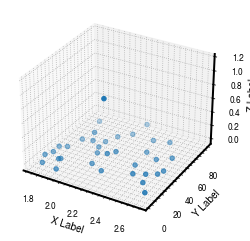

In [38]:
data2=np.array(data).T

# Plot a sin curve using the x and y axes.
x = data2[0]
y = data2[1]
z = data2[2]

import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(x, y, z)

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

plt.show()

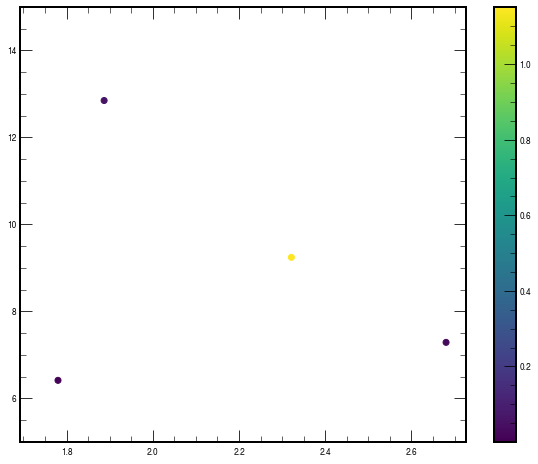

In [39]:
fig = plt.figure(figsize=(10,8))

plt.scatter(abs(x), y, c=z)
plt.colorbar(cmap="raimbow")
plt.ylim(5,15)
plt.show()

In [23]:
MAX = 0.1
NPOINTS = 100
thresholds = np.linspace(0, MAX, NPOINTS)

allEnergyShared = np.zeros(NPOINTS)
allEnergyTotal = np.zeros(NPOINTS)
allFractionShared = np.zeros(NPOINTS)
allFractionTotal = np.zeros(NPOINTS)
allFractionPileup = np.zeros(NPOINTS)

def energy_at_thr(dist, energy, tr=np.linspace(0, MAX, NPOINTS)):
    idx = np.searchsorted(dist, tr, side="right") - 1
    arr = [energy[i] if i>=0 else 0 for i in idx]
    return np.array(arr)

for distanceShare, energyShare, fractionShare, distanceAll, energyAll, fractionAll, pileup in zip(
    distanceSharedList, energySharedList, fractionSharedList, distanceTotalList, energyTotalList, fractionTotalList, fractionPileupList):
    
    # Aggregate totals
    allEnergyShared += energy_at_thr(distanceShare, energyShare)
    allEnergyTotal += energy_at_thr(distanceAll, energyAll)
    allFractionShared += energy_at_thr(distanceShare, fractionShare)
    allFractionTotal += energy_at_thr(distanceAll, fractionAll)
    allFractionPileup += energy_at_thr(distanceShare, pileup)

allEnergyShared /= len(distanceSharedList)
allEnergyTotal /= len(distanceSharedList)
allFractionShared /= len(distanceSharedList)
allFractionTotal /= len(distanceSharedList)
allFractionPileup /= len(distanceSharedList)

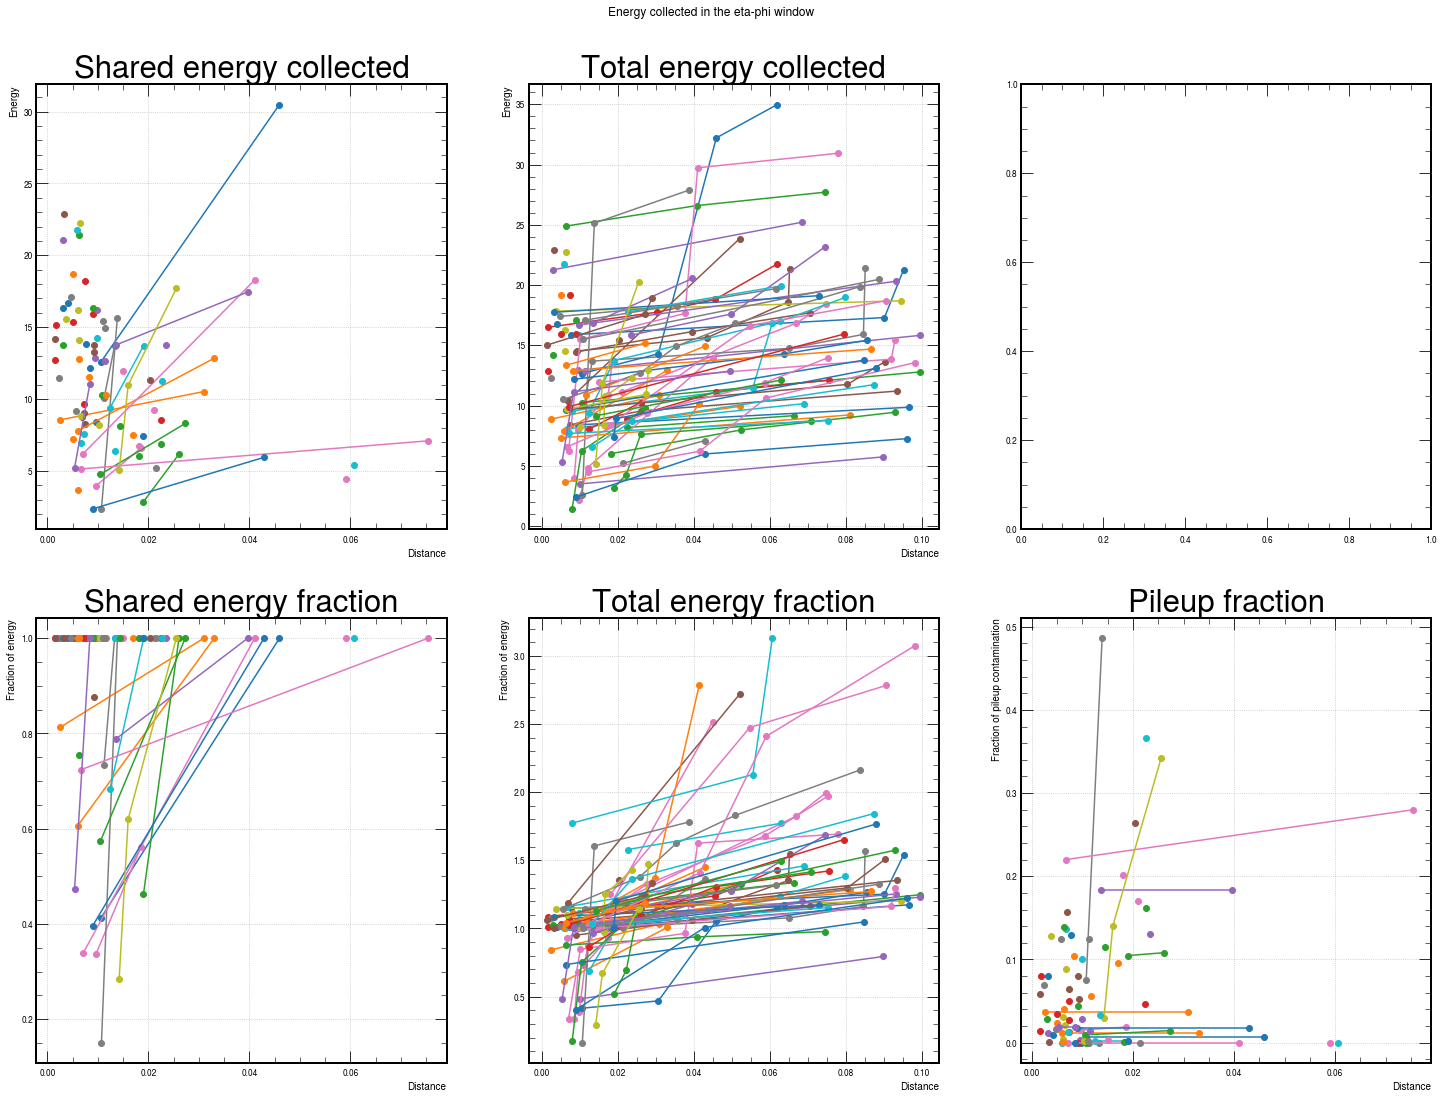

In [24]:
fig, axs = plt.subplots(2, 3, figsize=(25, 18))
fig.suptitle("Energy collected in the eta-phi window", y=0.94)
ax1, ax2, ax3, ax4, ax5, ax6 = axs[0][0], axs[0][1], axs[1][0], axs[1][1], axs[0][2], axs[1][2]
plt.style.use(hep.style.CMS)

CUT_PLOT=0.1

# Plot per-event data
for distanceShare, energyShare, fractionShare, distanceAll, energyAll, fractionAll, pileup in zip(
    distanceSharedList, energySharedList, fractionSharedList, distanceTotalList, energyTotalList, fractionTotalList, fractionPileupList):
    ax1.plot(distanceShare[distanceShare<=CUT_PLOT], energyShare[distanceShare<=CUT_PLOT], marker='o', linestyle='-')
    ax2.plot(distanceAll[distanceAll<=CUT_PLOT], energyAll[distanceAll<=CUT_PLOT], marker='o', linestyle='-')  
    ax3.plot(distanceShare[distanceShare<=CUT_PLOT], fractionShare[distanceShare<=CUT_PLOT], marker='o', linestyle='-')
    ax4.plot(distanceAll[distanceAll<=CUT_PLOT], fractionAll[distanceAll<=CUT_PLOT], marker='o', linestyle='-')  
    ax6.plot(distanceShare[distanceShare<=CUT_PLOT], pileup[distanceShare<=CUT_PLOT], marker='o', linestyle='-')  

# Labels and formatting
ax1.set_xlabel("Distance")
ax1.set_ylabel("Energy")
ax1.set_title("Shared energy collected")
ax1.grid(True)

ax2.set_xlabel("Distance")
ax2.set_ylabel("Energy")
ax2.set_title("Total energy collected")
ax2.grid(True)

ax3.set_xlabel("Distance")
ax3.set_ylabel("Fraction of energy")
ax3.set_title("Shared energy fraction")
ax3.grid(True)

ax4.set_xlabel("Distance")
ax4.set_ylabel("Fraction of energy")
ax4.set_title("Total energy fraction")
ax4.grid(True)

ax6.set_xlabel("Distance")
ax6.set_ylabel("Fraction of pileup contamination")
ax6.set_title("Pileup fraction")
ax6.grid(True)

plt.show()
# plt.savefig(f"plots/EnergyInWindow{PU}PU.png")

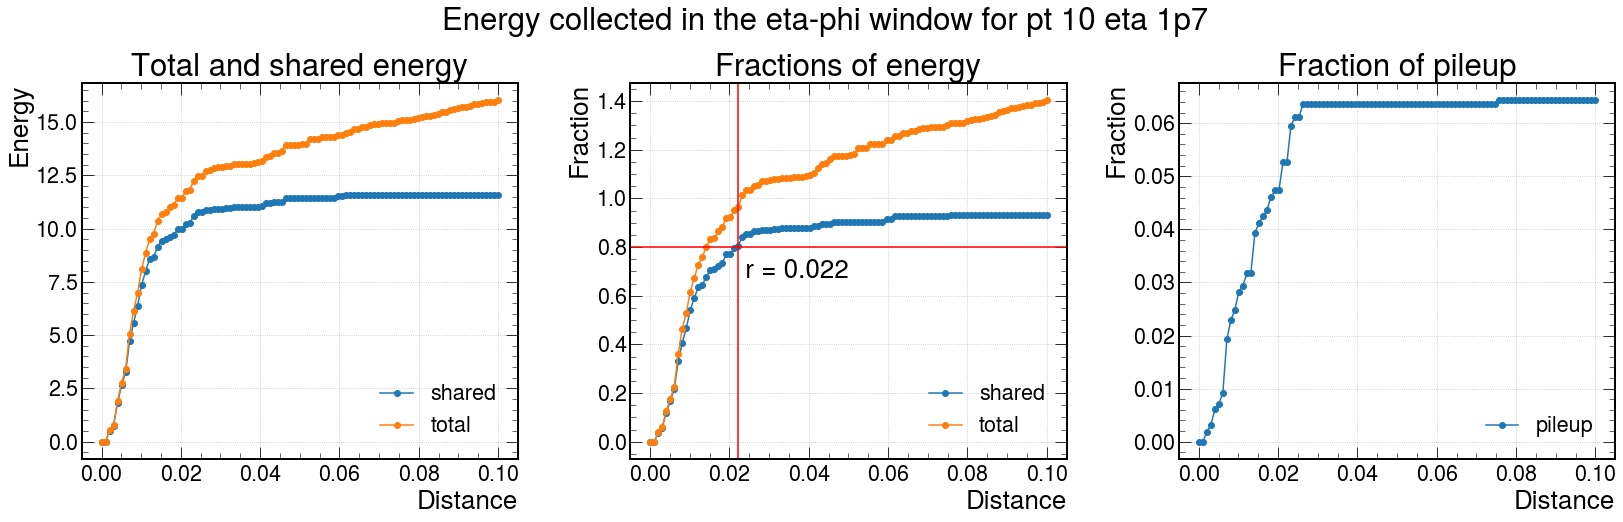

In [50]:
# Plot results
fig, axs = plt.subplots(1, 3, figsize=(23, 8))
fig.suptitle("Energy collected in the eta-phi window for pt 10 eta 1p7", y=0.93)
plt.style.use(hep.style.CMS)

ax1, ax2, ax3 = axs[0], axs[1], axs[2]

ax1.plot(thresholds, allEnergyShared, marker='o', linestyle='-', label='shared')
ax1.plot(thresholds, allEnergyTotal, marker='o', linestyle='-', label='total')
ax1.set_xlabel("Distance")
ax1.set_ylabel("Energy")
ax1.set_title("Total and shared energy")
ax1.legend()
ax1.grid(True)

ax2.plot(thresholds, allFractionShared, marker='o', linestyle='-', label='shared')
ax2.plot(thresholds, allFractionTotal, marker='o', linestyle='-', label='total')
ax2.axhline(0.8, color="red")
ax2.axvline(thresholds[np.where(allFractionShared>0.8)[0][0]], color="red")
ax2.text(thresholds[np.where(allFractionShared>0.8)[0][0]], 0.75, f" r = {thresholds[np.where(allFractionShared>0.8)[0][0]]:.3f}", ha='left', va='top')
ax2.set_xlabel("Distance")
ax2.set_ylabel("Fraction")
ax2.set_title("Fractions of energy")
ax2.legend()
ax2.grid(True)

ax3.plot(thresholds, allFractionPileup, marker='o', linestyle='-', label='pileup')
ax3.set_xlabel("Distance")
ax3.set_ylabel("Fraction")
ax3.set_title("Fraction of pileup")
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()
#plt.savefig(f"plots/cumulativeEnergyInWindow{PU}PU.png")

## cuts

In [ ]:
import pandas as pd

In [17]:
lista = [[10, 50, 100], [0.02, 0.015, 0.01], [0.03, 0.025, 0.02]]
df = pd.DataFrame(np.array(lista).T, columns=["energy", "eta=1.7", "eta=2.5"])
df["m"] = (df["eta=2.5"] - df["eta=1.7"]) / (2.5 - 1.7)
df["q"] = df["eta=1.7"] - df["m"] * 1.7
df

,energy,eta=1.7,eta=2.5,m,q
0,10.0,0.020,0.030,0.0125,-0.00125
1,50.0,0.015,0.025,0.0125,-0.00625
2,100.0,0.010,0.020,0.0125,-0.01125


In [19]:
lista = [[10, 50, 100], [0.03, 0.025, 0.02], [0.04, 0.035, 0.03]]
df = pd.DataFrame(np.array(lista).T, columns=["energy", "eta=1.7", "eta=2.5"])
df["m"] = (df["eta=2.5"] - df["eta=1.7"]) / (2.5 - 1.7)
df["q"] = df["eta=1.7"] - df["m"] * 1.7
df

,energy,eta=1.7,eta=2.5,m,q
0,10.0,0.030,0.040,0.0125,0.00875
1,50.0,0.025,0.035,0.0125,0.00375
2,100.0,0.020,0.030,0.0125,-0.00125
